# BeSS Database Access Example
Created by Philip and Gemini, May 2026

## Imports
Install pyvo if needed

In [41]:
# !pip install pyvo

In [42]:
import pyvo as vo
import urllib.request
import os

# Define the BeSS SSAP service URL
bess_service_url = "http://basebe.obspm.fr/cgi-bin/ssapBE_1.0.pl?"

from astropy.coordinates import SkyCoord
import astropy.units as u
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np

from astropy.time import Time
from collections import defaultdict

## Query BeSS for spectra
We need to start with the coordinates of interest, so we will just use astropy skycoord.

We can get more spectra of this source, if we want, by using the optional parameter `MAXREC`. Default is 300.

In [44]:
# target_name = 'V442 And'
# target_name = 'Lam Eri'
# target_name = 'Bet CMi'
# target_name = 'V1294 Aql'
target_name = '20 Vul'

target_coord = SkyCoord.from_name(target_name)

# Query the BeSS database via SSA (Simple Spectral Access) within a given search radius (size) of target coordinates.
print("Querying BeSS database...")
results = vo.dal.ssa.search(bess_service_url, pos=target_coord, size=0.1, MAXREC=10000)

# Convert results to an Astropy Table for easier filtering
results_table = results.to_table()
print(f"Found {len(results_table)} spectra for this region.")

Querying BeSS database...
Found 275 spectra for this region.


We can also query by target name, though this might not work if the same name isn't in the database.

In [45]:
# # Or query the BeSS database via SSA (Simple Spectral Access) using a target name.
# print("Querying BeSS database...")
# results = vo.dal.ssa.search(bess_service_url, TARGETNAME="Kap Dra", MAXREC=10000)

# # Convert results to an Astropy Table for easier filtering
# results_table = results.to_table()
# print(f"Found {len(results_table)} spectra for this region.")

In [46]:
# # Sort by date
results_table.sort('Midpoint of Exposure in MJD', reverse=True)

results_table

dataset access URL,MIME type of dataset,Dataset Data Model,number of points in spectrum,Dataset Title,Publisher,"Observed position, e.g. RA DEC","Aperture angular diameter, deg",Midpoint of Exposure in MJD,Central Wavelength,width of the spectrum in Angstrom or other unit,score,SI Factor and Dimension for Time,Spectral Axis name,SI Factor and Dimension for Spectral,Flux Axis name,SI Factor and Dimension for Flux,Creator Name,Collection shortname,Dataset ID assigned by creator,original source of data,Dataset Creation Type,URL or Bibcode for documentation,ID assigned by a publisher,Spatial coordinate frame,ucd for Flux,ucd for spectral coord,total exposure time,start in spectral coordinate,stop in spectral coordinate,astrometric statistical error,Type of flux calibration,Type of spectral coord calibration,Type of spatial coord calibration,Spectral resolution FWHM,Spatial resolution FWHM,rough dataset size,type of association,unique ID for entire association,unique ID for element of association,type of dataset,IVOA Dataset ID,Data processing/creation date,version of the dataset,instrument name (identifier),"bandpass name, e.g. filter",Data curated dataset last modified,Version of curated dataset,"Restrictions: public, proprietary, etc.",target name,target or object class,redshift of the object,typical variablilty amplitude,signal-to-noise ratio,Equinox,Timescale,Zero point of timescalein MJD,Aperture Region,Aperture Filling Factor,Filling Factor for a Bandwidth,start time,stop time,effective exposure time,Filling Factor for Exposure,flux value systematic error,flux value statistical error,spectral coordinate systematic error,spectral coordinate statistical error,temporal systematic error,temporal statistical error,astrometric systematic error,Type of time coord calibration,wavelength bin size,time bin size,temporal resolution FWHM
,,,,,,deg,,d,,Angstrom,,,,,,,,,,,,,,,,,s,m,m,deg,,,,m,deg,Byte,,,,,,,,,,,,,,,,,,,,,,,,,,s,,,,Angstrom,Angstrom,d,d,deg,,Angstrom,,s
object,object,object,int64,object,object,float64[2],float64,float64,float64,float64,float64,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,float64,float64[2],float64[2],float32,object,object,object,float32,float32,int64,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,float64,object,float64,object,float32,float32,object,object,float64,float32,float32,float32,float32,float32,float32,float32,float32,object,float32,float32,object
http://basebe.obspm.fr/cgi-bin/extBeSS.pl?fits=A_ogayrard%2F80edstarex2400asi585mm%2F_20_vul_20260705_952.fits,application/fits,Spectrum-1.0,5352,BeSS:20 Vul,Observatoire de Paris-Meudon -> GEPI,303.00292203 .. 26.47880657,--,61226.960845601854,6.599970703125e-07,1.998681640625e-08,--,T,WAVE,1. L,FLUX,,BeSS,BeSS-Spectra,,observed,pointed,,ivo://voparis-obspm-gepi/BeStars/BeSS#spectrum_376175,FK5,,phot.flux;em.wl,1500.0,6.50003662109375e-07 .. --,6.69990478515625e-07 .. --,--,Uncalibrated,Calibrated,,6.5999706e-11,--,0,,,,,,,,,,2026-07-12,1.0,public,20 Vul,Star,,,,2000.0,,--,,--,--,2026-07-05 22:51:07.06,2026-07-05 23:16:07.059999,--,--,--,--,--,--,--,--,--,,--,--,
http://basebe.obspm.fr/cgi-bin/extBeSS.pl?fits=A_pfricker%2Fc11lhiresiii23umasi533mmpro%2F_20vul_20250529_122_bess.fits,application/fits,Spectrum-1.0,5440,BeSS:20 Vul,Observatoire de Paris-Meudon -> GEPI,303.00292203 .. 26.47880657,--,60824.13273350694,6.56498046875e-07,1.2994873046875e-08,--,T,WAVE,1. L,FLUX,,BeSS,BeSS-Spectra,,observed,pointed,,ivo://voparis-obspm-gepi/BeStars/BeSS#spectrum_330865,FK5,,phot.flux;em.wl,1800.0,6.500005859375e-07 .. --,6.62995458984375e-07 .. --,--,Uncalibrated,Calibrated,,3.6472114e-11,--,0,,,,,,,,,,2025-06-13,1.0,public,20 Vul,Star,,,,2000.0,,--,,--,--,2025-05-29 02:56:08.175,2025-05-29 03:26:08.174999,--,--,--,--,--,--,--,--,--,,--,--,
http://basebe.obspm.fr/cgi-bin/extBeSS.pl?fits=A_jterry%2Fc11lhires129sbigst8300%2F_20vul_202407

In [47]:
results_table.colnames

['dataset access URL',
 'MIME type of dataset',
 'Dataset Data Model',
 'number of points in spectrum',
 'Dataset Title',
 'Publisher',
 'Observed position, e.g. RA DEC',
 'Aperture angular diameter, deg',
 'Midpoint of Exposure in MJD',
 'Central Wavelength',
 'width of the spectrum in Angstrom or other unit',
 'score',
 'SI Factor and Dimension for Time',
 'Spectral Axis name',
 'SI Factor and Dimension for Spectral',
 'Flux Axis name',
 'SI Factor and Dimension for Flux',
 'Creator Name',
 'Collection shortname',
 'Dataset ID assigned by creator',
 'original source of data',
 'Dataset Creation Type',
 'URL or Bibcode for documentation',
 'ID assigned by a publisher',
 'Spatial coordinate frame',
 'ucd for Flux',
 'ucd for spectral coord',
 'total exposure time',
 'start in spectral coordinate',
 'stop in spectral coordinate',
 'astrometric statistical error',
 'Type of flux calibration',
 'Type of spectral coord calibration',
 'Type of spatial coord calibration',
 'Spectral resoluti

## Bulk download of files 
Remove the `[:10]` slice to get all spectra from the query above.

This could be updated to only download files that haven't been downloaded previously by checking filenames. It might also be nice to give them more sensible filenames...

In [48]:
output_dir = f"./bess_downloads/{target_name}/"
os.makedirs(output_dir, exist_ok=True)

bess_wavelengths = []

# for row in results_table[:100]:
for row in results_table:
    # Get the direct download URL for the FITS file
    download_url = row['dataset access URL'] 
    filename = os.path.join(output_dir, download_url.split('=')[-1])

    print(f"Downloading {filename}...")
    try:
        urllib.request.urlretrieve(download_url, filename)
    except Exception as e:
        print(f"Failed to download {download_url}: {e}")
    
    center_wavelength = row['Central Wavelength']
    wave_width = row['width of the spectrum in Angstrom or other unit']

    bess_wavelengths.append([center_wavelength, wave_width])

## Plot Spectrum Example

This simply shows the plotting of the first downloaded spectrum, but could be easily adapted to loop through all spectra and plot them together or separately.

In [30]:
# Plot first spectrum
# Load the first downloaded FITS file
first_fits = os.path.join(output_dir, os.listdir(output_dir)[20])
with fits.open(first_fits) as hdul:
    data = hdul[1].data  # Assuming the spectrum is in the first extension
    date_obs = hdul[0].header['DATE-OBS']
    print(f"Observation date: {date_obs}")

wavelength = data['WAVE']
flux = data['FLUX']

Observation date: 2019-10-01T19:04:27


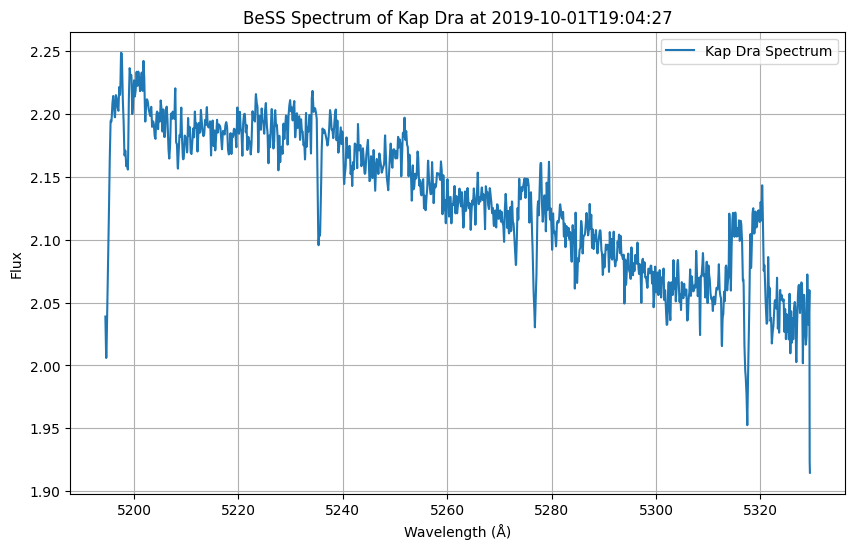

In [31]:
# Plot
plt.figure(figsize=(10, 6))
plt.plot(wavelength, flux, label='Kap Dra Spectrum')
plt.xlabel('Wavelength (Å)')
plt.ylabel('Flux')
plt.title(f'BeSS Spectrum of Kap Dra at {date_obs}')
plt.legend()
plt.grid()
plt.show()

# Plot All Spectra

In [49]:
halpha_window = (6550, 6575)
halpha_center = 6562.8

bess_spectra = []

# Optional: set this to something like 5 / (24*60) for 5 minutes
# if split spectra have slightly different DATE-OBS values
time_group_tolerance_days = 0.0

raw_spectra = []

for file in os.listdir(output_dir):

    if not file.lower().endswith((".fits", ".fit", ".fts")):
        continue

    fits_file = os.path.join(output_dir, file)
    print(f"Processing {fits_file}...")

    try:
        with fits.open(fits_file, ignore_missing_simple=True) as hdul:
            data = hdul[1].data
            date_obs = hdul[0].header["DATE-OBS"]

            wavelength = np.asarray(data["WAVE"], dtype=float)
            flux = np.asarray(data["FLUX"], dtype=float)

        raw_spectra.append({
            "file": file,
            "wave": wavelength,
            "flux": flux,
            "date_obs": date_obs,
            "time": Time(date_obs)
        })

    except Exception as e:
        print(f"Failed to process {fits_file}: {e}")

Processing ./bess_downloads/20 Vul/A_othizy%2Feshelatik460%2F_20vul_20210709_966_45.fits...
Processing ./bess_downloads/20 Vul/A_othizy%2Feshelatik460%2F_20vul_20160728_893_51.fits...
Processing ./bess_downloads/20 Vul/A_othizy%2Feshelatik460%2F_20vul_20210628_040_32.fits...
Processing ./bess_downloads/20 Vul/A_othizy%2Feshelatik460%2F_20vul_20200805_915_31.fits...
Processing ./bess_downloads/20 Vul/A_othizy%2Feshelatik460%2F_20vul_20160728_893_47.fits...
Processing ./bess_downloads/20 Vul/A_othizy%2Feshelatik460%2F_20vul_20210709_966_53.fits...
Processing ./bess_downloads/20 Vul/A_cbuil%2Frc10eshel2asi1600mm%2F_20vul_20180624_035_31.fits...
Processing ./bess_downloads/20 Vul/A_cbuil%2Fnewton250vhiresmoasi1600mm%2F_20vul_20200410_077_41.fits...
Processing ./bess_downloads/20 Vul/A_scharbonnel%2Ft500f5ap3600ec2eshel112atik460ex%2F_20vul_20190920_891_48.fits...
Processing ./bess_downloads/20 Vul/A_kgraham%2Flx20012lhires240035ust8xme%2F_hd192044_20160919_015_kgraham.fits...
Processing ./

In [50]:
raw_spectra.sort(key=lambda s: s["time"].jd)

groups = []

for spec in raw_spectra:

    if len(groups) == 0:
        groups.append([spec])
        continue

    dt = abs(spec["time"].jd - groups[-1][0]["time"].jd)

    if dt <= time_group_tolerance_days:
        groups[-1].append(spec)
    else:
        groups.append([spec])

In [51]:
bess_spectra = []

for group in groups:

    date_obs = group[0]["date_obs"]
    time = group[0]["time"]

    all_wave = np.concatenate([g["wave"] for g in group])
    all_flux = np.concatenate([g["flux"] for g in group])

    sort_idx = np.argsort(all_wave)
    all_wave = all_wave[sort_idx]
    all_flux = all_flux[sort_idx]

    # Remove duplicate / invalid wavelength points
    good = np.isfinite(all_wave) & np.isfinite(all_flux)
    all_wave = all_wave[good]
    all_flux = all_flux[good]

    # Check whether stitched spectrum satisfies the H-alpha window
    has_full_halpha_window = (
        np.nanmin(all_wave) <= halpha_window[0]
        and np.nanmax(all_wave) >= halpha_window[1]
    )

    if not has_full_halpha_window:
        print(f"Skipping {date_obs}: does not cover full H-alpha window after stitching")
        continue

    # Trim to H-alpha window immediately
    mask = (all_wave >= halpha_window[0]) & (all_wave <= halpha_window[1])

    bess_spectra.append({
        "wave": all_wave[mask],
        "flux": all_flux[mask],
        "date_obs": date_obs,
        "time": time,
        "files": [g["file"] for g in group]
    })

bess_spectra.sort(key=lambda s: s["time"].jd)

print(f"Loaded {len(bess_spectra)} stitched BeSS spectra covering H-alpha.")

Skipping 1986-05-02T04:50:41.0000: does not cover full H-alpha window after stitching
Skipping 1986-05-02T05:13:31.0000: does not cover full H-alpha window after stitching
Loaded 64 stitched BeSS spectra covering H-alpha.


In [52]:
# print(groups[289][27]['date_obs'])

In [53]:
# with fits.open(os.path.join(output_dir, groups[289][27]['file'])) as hdul:
#     data = hdul[1].data
#     header = hdul[0].header
#     spec_res = hdul[0].header["BSS_ITRP"] if "BSS_ITRP" in hdul[0].header else hdul[0].header.get("SPE_RPOW", None)

#     print(spec_res)

# header

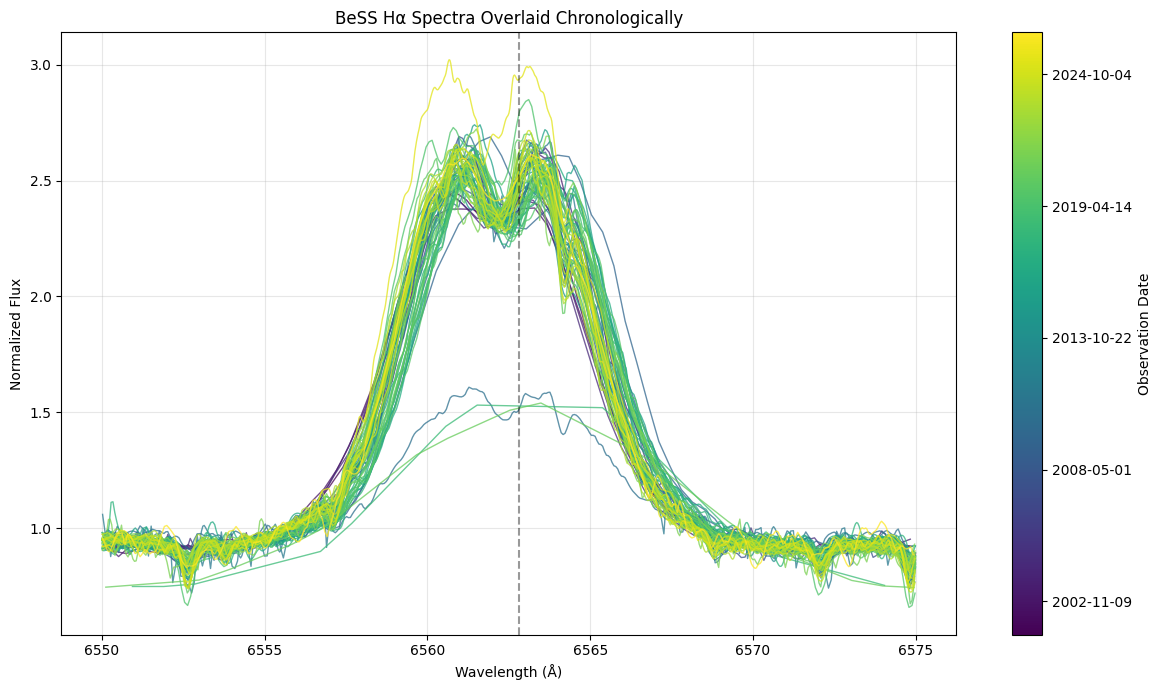

In [54]:
import matplotlib.dates as mdates
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

fig, ax = plt.subplots(figsize=(12, 7))

times = np.array([spec["time"].datetime for spec in bess_spectra])
date_nums = mdates.date2num(times)

norm = Normalize(vmin=date_nums.min(), vmax=date_nums.max())
cmap = plt.cm.viridis

for spec, date_num in zip(bess_spectra, date_nums):

    wave = spec["wave"]
    flux = spec["flux"]

    norm_flux = flux / np.nanmedian(flux)

    ax.plot(
        wave,
        norm_flux,
        lw=1,
        alpha=0.75,
        color=cmap(norm(date_num))
    )

ax.axvline(6562.8, color="k", ls="--", alpha=0.4)

sm = ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

cbar = fig.colorbar(sm, ax=ax)
cbar.set_label("Observation Date")
cbar.ax.yaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))

ax.set_xlabel("Wavelength (Å)")
ax.set_ylabel("Normalized Flux")
ax.set_title("BeSS Hα Spectra Overlaid Chronologically")
# ax.set_ylim(0.8, 2.5)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [55]:
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np

wave_grid = np.linspace(halpha_window[0], halpha_window[1], 1000)

flux_grid = []
date_nums = []
kept_specs = []

for spec in bess_spectra:

    wave = np.asarray(spec["wave"], dtype=float)
    flux = np.asarray(spec["flux"], dtype=float)

    good = np.isfinite(wave) & np.isfinite(flux)
    wave = wave[good]
    flux = flux[good]

    # Important guard
    if len(wave) < 2 or len(flux) < 2:
        print(f"Skipping empty/invalid spectrum: {spec['date_obs']}")
        continue

    # Sort just in case
    sort_idx = np.argsort(wave)
    wave = wave[sort_idx]
    flux = flux[sort_idx]

    # Only keep spectrum if it actually overlaps the plotting window
    overlap = (wave >= halpha_window[0]) & (wave <= halpha_window[1])

    if np.sum(overlap) < 2:
        print(f"Skipping no-overlap spectrum: {spec['date_obs']}")
        continue

    wave = wave[overlap]
    flux = flux[overlap]

    norm_flux = flux / np.nanmedian(flux)

    interp = interp1d(
        wave,
        norm_flux,
        bounds_error=False,
        fill_value=np.nan,
        assume_sorted=True
    )

    flux_grid.append(interp(wave_grid))
    date_nums.append(mdates.date2num(spec["time"].datetime))
    kept_specs.append(spec)

flux_grid = np.asarray(flux_grid)
date_nums = np.asarray(date_nums)

print(f"Using {len(kept_specs)} spectra in dynamic plot.")

Using 64 spectra in dynamic plot.


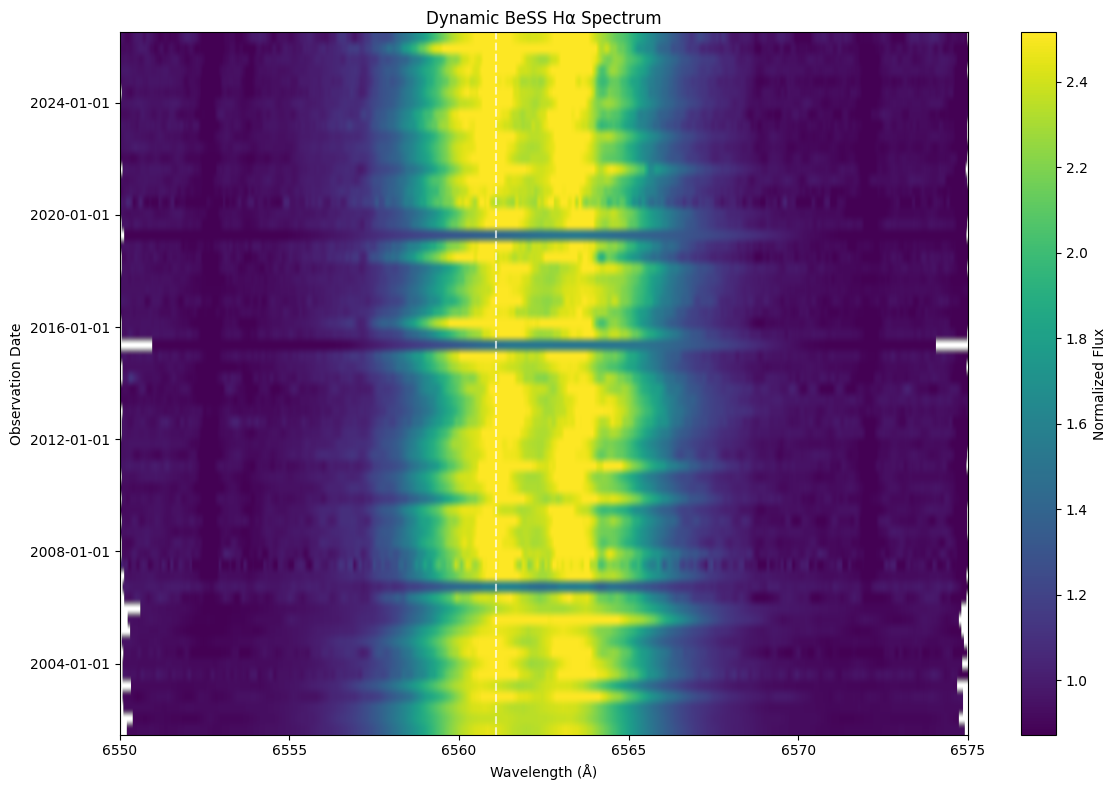

In [56]:
fig, ax = plt.subplots(figsize=(12, 8))

vmin, vmax = np.nanpercentile(flux_grid, [5, 95])

im = ax.imshow(
    flux_grid,
    aspect="auto",
    origin="lower",
    extent=[
        wave_grid.min(),
        wave_grid.max(),
        date_nums.min(),
        date_nums.max()
    ],
    cmap="viridis",
    vmin=vmin,
    vmax=vmax
)

# ax.axvline(6562.8, color="w", ls="--", alpha=0.7)
ax.axvline(6561.1, color="w", ls="--", alpha=0.7)

ax.set_xlabel("Wavelength (Å)")
ax.set_ylabel("Observation Date")
ax.set_title("Dynamic BeSS Hα Spectrum")

ax.yaxis_date()
ax.yaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Normalized Flux")

plt.tight_layout()
plt.show()